# Generate data and save in a file

In [1]:
from sklearn import datasets
import numpy as np

In [2]:
c = np.array([[4, 3], [7, 7]])
X, y = datasets.make_blobs(n_samples=30,n_features=2,
                           centers=c, cluster_std=1,
                           random_state=727)

In [3]:
with open("perceptron_data.txt", "w") as f:
    f.write("x1\tx2\tlabel\n")
    for i in range(len(X)):
        f.write(f'{X[i][0]:.2f}' + '\t' + f'{X[i][1]:.2f}' + '\t' + f'{y[i]}' +'\n')

# Loading the dataset

In [4]:
import pandas as pd

df = pd.read_csv("perceptron_data.txt", sep='\t')
df.head()

,x1,x2,label
0,3.28,3.20,0
1,1.91,3.00,0
2,3.26,1.81,0
3,7.78,5.83,1
4,6.81,5.51,1


In [5]:
X_train = df[["x1", "x2"]].values
y_train = df["label"].values

In [6]:
X_train

array([[3.28, 3.2 ],
       [1.91, 3.  ],
       [3.26, 1.81],
       [7.78, 5.83],
       [6.81, 5.51],
       [4.86, 2.63],
       [3.81, 3.21],
       [6.2 , 6.21],
       [7.74, 6.16],
       [4.87, 1.56],
       [6.89, 6.98],
       [6.48, 9.07],
       [7.07, 7.14],
       [4.66, 2.66],
       [6.47, 7.65],
       [5.38, 7.  ],
       [5.92, 1.68],
       [2.62, 1.84],
       [7.3 , 6.34],
       [3.59, 2.37],
       [4.71, 5.22],
       [3.57, 1.35],
       [6.04, 8.09],
       [6.39, 6.56],
       [4.51, 3.73],
       [3.02, 3.36],
       [6.51, 7.66],
       [5.81, 7.21],
       [6.04, 6.2 ],
       [2.18, 1.45]])

In [7]:
y_train

array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0])

In [8]:
X_train.shape

(30, 2)

In [9]:
np.bincount(y_train)

array([15, 15])

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

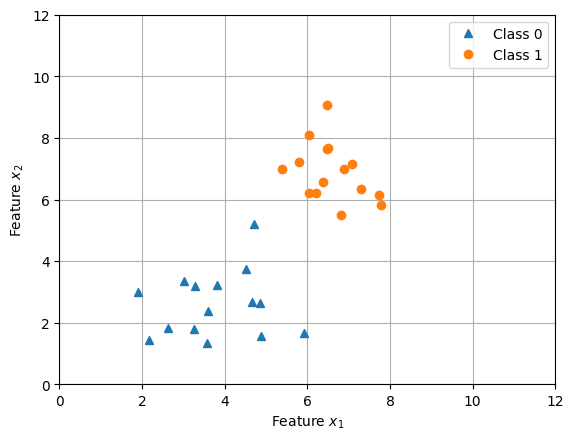

In [11]:
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], '^', label="Class 0")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 'o', label="Class 1")
plt.ylim(0,12)
plt.xlim(0,12)
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$")
plt.legend()
plt.grid()
plt.show()

# Perceptron Class

In [12]:
class Perceptron:
    def __init__(self, num_features):
        self.weights = [0.0 for _ in range(num_features)]
        self.bias = 0.0

    def forward(self, x):
        z_weighted_sum = self.bias
        for i, _ in enumerate(self.weights):
            z_weighted_sum += x[i] * self.weights[i]

        if z_weighted_sum > 0.0:
            prediction = 1
        else:
            prediction = 0

        return prediction

    def update(self, x, true_y):
        y_hat = self.forward(x)
        error = true_y - y_hat

        self.bias += error
        for i, _ in enumerate(self.weights):
            self.weights[i] += error * x[i]

        return error

In [13]:
pn = Perceptron(num_features=2)

In [14]:
pn.weights

[0.0, 0.0]

In [15]:
pn.bias

0.0

In [16]:
x = [1.0, 2.0]
pn.forward(x)

0

In [17]:
pn.update(x, 1)

1

In [18]:
print(pn.weights)

[1.0, 2.0]


# Train function

In [19]:
def train(model, X_data, y_labels, epochs):
    for epoch in range(epochs):
        error_count = 0
        
        for x, y in zip(X_data, y_labels):
            error = model.update(x, y)
            error_count += abs(error)
            
        print(f'Epoch {epoch+1}, errors {error_count}')

In [20]:
pn = Perceptron(2)

In [21]:
train(pn, X_train, y_train, epochs=110)

Epoch 1, errors 17
Epoch 2, errors 15
Epoch 3, errors 11
Epoch 4, errors 11
Epoch 5, errors 10
Epoch 6, errors 10
Epoch 7, errors 7
Epoch 8, errors 8
Epoch 9, errors 6
Epoch 10, errors 5
Epoch 11, errors 8
Epoch 12, errors 6
Epoch 13, errors 5
Epoch 14, errors 8
Epoch 15, errors 5
Epoch 16, errors 7
Epoch 17, errors 7
Epoch 18, errors 5
Epoch 19, errors 5
Epoch 20, errors 5
Epoch 21, errors 7
Epoch 22, errors 7
Epoch 23, errors 5
Epoch 24, errors 5
Epoch 25, errors 5
Epoch 26, errors 4
Epoch 27, errors 4
Epoch 28, errors 5
Epoch 29, errors 5
Epoch 30, errors 5
Epoch 31, errors 5
Epoch 32, errors 4
Epoch 33, errors 4
Epoch 34, errors 5
Epoch 35, errors 5
Epoch 36, errors 5
Epoch 37, errors 4
Epoch 38, errors 4
Epoch 39, errors 5
Epoch 40, errors 5
Epoch 41, errors 4
Epoch 42, errors 3
Epoch 43, errors 3
Epoch 44, errors 4
Epoch 45, errors 3
Epoch 46, errors 3
Epoch 47, errors 5
Epoch 48, errors 4
Epoch 49, errors 3
Epoch 50, errors 3
Epoch 51, errors 4
Epoch 52, errors 3
Epoch 53, error

# Evaluate accuracy

In [22]:
def compute_accuracy(model, X_data, y_label):
    correct = 0.0
    
    for x, y in zip(X_data, y_label):
        prediction = model.forward(x)
        correct += int(prediction == y)
        
    return correct / len(y_label)

In [23]:
train_acc = compute_accuracy(pn, X_train, y_train)
train_acc

1.0

In [24]:
print(f'Accuracy: {train_acc*100}%')

Accuracy: 100.0%


# Plot decision boundary

In [25]:
def plot_decision_boundary(model):
    w1 = model.weights[0]
    w2 = model.weights[1]
    b = model.bias
    
    assert w2 != 0
    
    x1_min = -100
    x2_min = (-b -(w1 * x1_min)) / w2
    
    x1_max = 100
    x2_max =( -b -(w1 * x1_max)) / w2
    
    return x1_min, x2_min, x1_max, x2_max

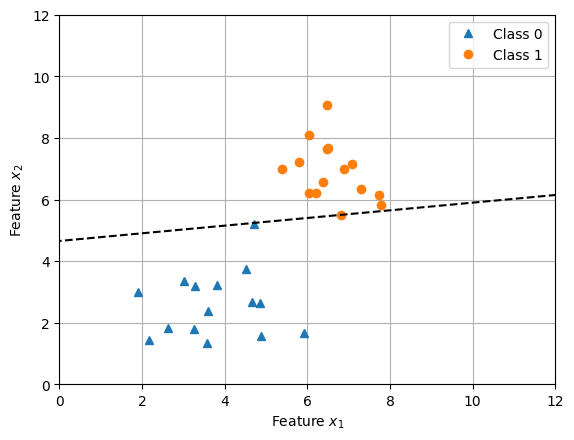

In [26]:
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], '^', label="Class 0")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 'o', label="Class 1")
plt.ylim(0,12)
plt.xlim(0,12)
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$")
plt.legend()
plt.grid()

x1_min, x2_min, x1_max, x2_max = plot_decision_boundary(pn)
plt.plot([x1_min, x1_max], [x2_min, x2_max], 'k--')

plt.show()